# Projeto 2 — Ablação de Arquiteturas

**Objetivo:** isolar o efeito de **duas** decisões de design, uma por vez,
mantendo tudo o mais constante (mesmo split, mesmas transformações, mesma seed,
mesmo otimizador, mesmo número de épocas).

Estilo de código idêntico ao das aulas 5 (partes 2 e 3): `nn.ReLU()` sem
`inplace`, `nn.Sequential`, `forward` explícita.

## As três arquiteturas

| | BatchNorm | Cabeça | Origem |
|---|---|---|---|
| **A — `sem_norm`** | não | `Flatten + Linear(32768, 256)` | estilo `MNISTCNN` (Aula 5 parte 2), estendido a 3 blocos |
| **B — `plantvillage`** | **sim** | `Flatten + Linear(32768, 256)` | `PlantVillageCNN` literal (Aula 5 parte 3) |
| **C — `gap`** | sim | `AdaptiveAvgPool2d(1) + Linear(128, 2)` | B com pooling global |

## O que cada comparação isola

- **A → B** mede o **efeito puro do BatchNorm**. Única diferença: presença de
  `nn.BatchNorm2d` após cada convolução. Mesma profundidade, mesma cabeça,
  mesmo Dropout.
- **B → C** mede o **efeito puro da cabeça densa**. Única diferença:
  `Flatten + Linear(32768, 256)` (8,4M parâmetros) contra
  `AdaptiveAvgPool2d(1) + Linear(128, 2)` (258 parâmetros).

Cada comparação muda **uma** variável. É isso que torna o efeito atribuível — e
é o que o enunciado pede ao exigir hipótese, correção e efeito medido.

## Nota sobre `inplace=True`

As aulas usam `nn.ReLU()` sem argumento. `nn.ReLU(inplace=True)` sobrescreve o
tensor de entrada em vez de alocar um novo: é **otimização de memória**, com
**zero efeito no resultado numérico**. Este notebook usa a forma das aulas para
manter a comparação limpa.

In [1]:
# ---------------------------------------------------------------
# 1. Ambiente
# ---------------------------------------------------------------
import os
import re
import json
import copy
from collections import Counter
from datetime import datetime
from pathlib import Path

import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score, roc_curve)

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")


def set_seed(seed=SEED):
    """Re-semeia antes de CADA arquitetura, para que a inicializacao dos pesos
    e a ordem dos batches sejam identicas nas tres. Sem isto a diferenca
    medida misturaria o efeito do design com o efeito do estado aleatorio."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed()


Dispositivo em uso: mps


In [2]:
# ---------------------------------------------------------------
# 2. Dados - pipeline identico ao de projeto2.ipynb
# ---------------------------------------------------------------
IMG_SIZE = 128
BATCH_SIZE = 32
VAL_FRACTION = 1 / 7

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
dataset_path = os.path.join(path, 'chest_xray')
train_dir = os.path.join(dataset_path, 'train')
full_train = ImageFolder(root=train_dir)
test_base = ImageFolder(root=os.path.join(dataset_path, 'test'))
class_names = full_train.classes

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

all_labels = np.array(full_train.targets)
PATIENT_ID_PATTERN = re.compile(r"person(\d+)_")
patient_groups = np.array([
    f"p{m.group(1)}" if (m := PATIENT_ID_PATTERN.match(os.path.basename(caminho)))
    else f"arquivo{i}"
    for i, (caminho, _) in enumerate(full_train.samples)
])
sgkf = StratifiedGroupKFold(n_splits=int(1 / VAL_FRACTION), shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(np.zeros(len(all_labels)), all_labels, patient_groups))
assert not (set(patient_groups[train_idx]) & set(patient_groups[val_idx])), "vazamento de grupo!"


class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset, self.transform = subset, transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        return (self.transform(x) if self.transform else x), y
    def __len__(self):
        return len(self.subset)


train_loader = DataLoader(ApplyTransform(Subset(full_train, train_idx), train_transform),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ApplyTransform(Subset(full_train, val_idx), eval_transform),
                        batch_size=64, shuffle=False)
test_loader = DataLoader(ApplyTransform(test_base, eval_transform),
                         batch_size=64, shuffle=False)

cont = Counter(all_labels[train_idx])
class_weights = torch.tensor(
    [len(train_idx) / (2 * cont[i]) for i in range(len(class_names))],
    dtype=torch.float).to(device)

print(f"treino {len(train_idx)} | val {len(val_idx)} | teste {len(test_base)}")
print(f"vazamento de paciente: {len(set(patient_groups[train_idx]) & set(patient_groups[val_idx]))}")
print(f"pesos de classe: {[round(w, 3) for w in class_weights.tolist()]}")


treino 4471 | val 745 | teste 624
vazamento de paciente: 0
pesos de classe: [1.944, 0.673]


In [3]:
# As tres arquiteturas. A espinha convolucional e a MESMA nas tres
# (3 blocos, 32->64->128, kernel 3, padding 1, MaxPool 2x2). So variam:
#   BatchNorm2d apos cada convolucao   -> A vs B
#   tipo de cabeca de classificacao    -> B vs C

def conv_block(cin, cout, use_batchnorm):
    """Um bloco convolucional. Com BatchNorm, a norma vem ANTES da ativacao,
    para controlar a distribuicao que entra na nao-linearidade."""
    camadas = [nn.Conv2d(cin, cout, kernel_size=3, padding=1)]
    if use_batchnorm:
        camadas.append(nn.BatchNorm2d(cout))
    camadas += [nn.ReLU(), nn.MaxPool2d(2, 2)]
    return camadas


class AblationCNN(nn.Module):
    """
    use_batchnorm : bool  -> insere nn.BatchNorm2d apos cada convolucao
    head_type    : 'flatten' | 'gap'
    """

    def __init__(self, num_classes=2, use_batchnorm=True, head_type='flatten'):
        super(AblationCNN, self).__init__()
        self.use_batchnorm = use_batchnorm
        self.head_type = head_type

        self.features = nn.Sequential(
            *conv_block(3, 32, use_batchnorm),     # 128 -> 64
            *conv_block(32, 64, use_batchnorm),    # 64  -> 32
            *conv_block(64, 128, use_batchnorm),   # 32  -> 16
        )

        if head_type == 'flatten':
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * 16 * 16, 256),
                nn.ReLU(),
                nn.Dropout(0.4),                    # 0.4, como na Aula 5 parte 3
                nn.Linear(256, num_classes),
            )
        elif head_type == 'gap':
            self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Dropout(0.4),
                nn.Linear(128, num_classes),
            )
        else:
            raise ValueError(f"head_type invalido: {head_type}")

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits


ARCHITECTURES = {
    "A_sem_norm":    dict(use_batchnorm=False, head_type='flatten'),
    "B_plantvillage": dict(use_batchnorm=True,  head_type='flatten'),
    "C_gap":          dict(use_batchnorm=True,  head_type='gap'),
}

print(f"{'arquitetura':16s} {'BatchNorm':>10s} {'cabeca':>9s} "
      f"{'features':>10s} {'cabeca':>12s} {'TOTAL':>12s}")
for name, cfg in ARCHITECTURES.items():
    m = AblationCNN(**cfg)
    nf = sum(p.numel() for p in m.features.parameters())
    nc = sum(p.numel() for p in m.classifier.parameters())
    print(f"{name:16s} {str(cfg['use_batchnorm']):>10s} {cfg['head_type']:>9s} "
          f"{nf:>10,} {nc:>12,} {nf+nc:>12,}")


arquitetura       BatchNorm    cabeca   features       cabeca        TOTAL
A_sem_norm            False   flatten     93,248    8,389,378    8,482,626
B_plantvillage         True   flatten     93,696    8,389,378    8,483,074
C_gap                  True       gap     93,696          258       93,954


In [4]:
# ---------------------------------------------------------------
# 4. Funcoes de treino e avaliacao (identicas para as tres)
# ---------------------------------------------------------------
from torch.utils.tensorboard import SummaryWriter

EPOCHS = 20
PATIENCE = 5
LR = 1e-3

RUNS_ROOT = Path("runs/projeto2")
ABLATION_DIR = RUNS_ROOT / f"ablacao_{datetime.now():%Y%m%d-%H%M%S}"
(ABLATION_DIR / "figuras").mkdir(parents=True, exist_ok=True)
print(f"results em {ABLATION_DIR}")


def predict_probs(model, loader):
    """Devolve (probabilidades de PNEUMONIA, rotulos verdadeiros)."""
    model.eval()
    P, Y = [], []
    with torch.no_grad():
        for x, y in loader:
            saida = model(x.to(device))
            P.extend(torch.softmax(saida, 1)[:, 1].cpu().numpy())
            Y.extend(y.numpy())
    return np.array(P), np.array(Y)


def compute_metrics(y, probs, thr=0.5):
    tn, fp, fn, tp = confusion_matrix(y, (probs >= thr).astype(int), labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
                acc=(tp + tn) / len(y), sens=sens, spec=spec, bal=(sens + spec) / 2,
                auroc=roc_auc_score(y, probs), auprc=average_precision_score(y, probs))


def train_model(name, cfg):
    set_seed()                                  # <- mesma inicializacao nas tres
    model = AblationCNN(**cfg).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, threshold=1e-3, min_lr=1e-6)
    writer = SummaryWriter(log_dir=str(ABLATION_DIR / name))

    history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[],
                val_auroc=[], lr=[])
    best_val_loss, epochs_no_improve, best_epoch, best_weights = float('inf'), 0, 0, None

    print(f"\n{'='*72}\n{name}  |  BatchNorm={cfg['use_batchnorm']}  "
          f"cabeca={cfg['head_type']}\n{'='*72}")

    for ep in range(EPOCHS):
        model.train()
        soma = acertos = n = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            saida = model(x)
            loss = criterion(saida, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            soma += loss.item() * x.size(0)
            acertos += (saida.argmax(1) == y).sum().item()
            n += y.size(0)
        train_loss, train_acc = soma / n, 100 * acertos / n

        model.eval()
        soma = acertos = n = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                saida = model(x)
                soma += criterion(saida, y).item() * x.size(0)
                acertos += (saida.argmax(1) == y).sum().item()
                n += y.size(0)
        val_loss, val_acc = soma / n, 100 * acertos / n
        pv, yv = predict_probs(model, val_loader)
        val_auroc = roc_auc_score(yv, pv)
        current_lr = optimizer.param_groups[0]['lr']

        for k, v in (('train_loss', train_loss), ('val_loss', val_loss),
                     ('train_acc', train_acc), ('val_acc', val_acc),
                     ('val_auroc', val_auroc), ('lr', current_lr)):
            history[k].append(v)
        writer.add_scalars("loss", {"treino": train_loss, "val": val_loss}, ep)
        writer.add_scalars("accuracy", {"treino": train_acc, "val": val_acc}, ep)
        writer.add_scalar("val/auroc", val_auroc, ep)
        writer.add_scalar("learning_rate", current_lr, ep)

        print(f"  ep{ep+1:2d} | tr {train_loss:.4f}/{train_acc:5.2f}% | "
              f"val {val_loss:.4f}/{val_acc:5.2f}% auroc {val_auroc:.4f} | "
              f"gap {train_acc-val_acc:+6.2f}pp | lr {current_lr:.1e}")

        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss, epochs_no_improve, best_epoch = val_loss, 0, ep + 1
            best_weights = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  early stopping na epoca {ep+1}")
                break

    model.load_state_dict(best_weights)
    torch.save({"model": best_weights, "epoca": best_epoch,
                "val_loss": best_val_loss, "config": cfg},
               ABLATION_DIR / f"{name}.pt")

    pv, yv = predict_probs(model, val_loader)
    px, yx = predict_probs(model, test_loader)
    mv, mx = compute_metrics(yv, pv), compute_metrics(yx, px)
    sweep = {f"{t:.2f}": {k: compute_metrics(yx, px, t)[k] for k in ('sens', 'spec', 'bal')}
             for t in (0.5, 0.7, 0.9, 0.95, 0.99)}
    res = dict(name=name, **cfg,
               params=sum(p.numel() for p in model.parameters()),
               n_epochs=len(history['train_loss']), best_epoch=best_epoch,
               auroc_val=mv['auroc'], teste=mx, sweep=sweep,
               delta_auroc=mv['auroc'] - mx['auroc'], history=history)
    writer.close()
    print(f"  -> AUROC val {mv['auroc']:.4f} | teste {mx['auroc']:.4f} "
          f"| delta {res['delta_auroc']:+.4f}")
    return res


results em runs/projeto2/ablacao_20260828-094233


In [5]:
# ---------------------------------------------------------------
# 5. Roda as tres  (~15 a 20 min no total)
# ---------------------------------------------------------------
results = {name: train_model(name, cfg) for name, cfg in ARCHITECTURES.items()}

with open(ABLATION_DIR / "resultados.json", "w") as f:
    json.dump(results, f, indent=2, default=float)
print(f"\nresultados salvos em {ABLATION_DIR / 'resultados.json'}")



A_sem_norm  |  BatchNorm=False  cabeca=flatten


  ep 1 | tr 0.3484/85.01% | val 0.1572/93.96% auroc 0.9919 | gap  -8.95pp | lr 1.0e-03


  ep 2 | tr 0.1619/94.45% | val 0.1289/94.77% auroc 0.9908 | gap  -0.31pp | lr 1.0e-03


  ep 3 | tr 0.1439/94.30% | val 0.1798/93.42% auroc 0.9914 | gap  +0.87pp | lr 1.0e-03


  ep 4 | tr 0.1305/95.01% | val 0.0980/96.51% auroc 0.9922 | gap  -1.50pp | lr 1.0e-03


...

  ep 8 | tr 0.2341/91.50% | val 0.1211/95.70% auroc 0.9897 | gap  -4.20pp | lr 5.0e-04


  ep 9 | tr 0.2245/91.57% | val 0.1482/93.56% auroc 0.9929 | gap  -1.99pp | lr 5.0e-04


  ep10 | tr 0.1996/92.19% | val 0.3084/88.19% auroc 0.9941 | gap  +4.01pp | lr 2.5e-04


  ep11 | tr 0.1952/92.48% | val 0.2178/91.41% auroc 0.9935 | gap  +1.08pp | lr 2.5e-04
  early stopping na epoca 11


  -> AUROC val 0.9908 | teste 0.9199 | delta +0.0709

resultados salvos em runs/projeto2/ablacao_20260828-094233/resultados.json


In [6]:
# ---------------------------------------------------------------
# 6. Tabela comparativa
# ---------------------------------------------------------------
print(f"{'arquitetura':16s} {'params':>11s} {'ep':>3s} {'AUROCval':>9s} "
      f"{'AUROCtst':>9s} {'delta':>8s} {'acc':>7s} {'sens':>7s} {'spec':>7s} {'bal':>7s}")
print("-" * 96)
for r in results.values():
    t = r['teste']
    print(f"{r['name']:16s} {r['params']:>11,} {r['n_epochs']:>3d} {r['auroc_val']:>9.4f} "
          f"{t['auroc']:>9.4f} {r['delta_auroc']:>+8.4f} {t['acc']:>7.1%} "
          f"{t['sens']:>7.1%} {t['spec']:>7.1%} {t['bal']:>7.1%}")

A, B, C = (results['A_sem_norm'], results['B_plantvillage'], results['C_gap'])

print("\n" + "=" * 72)
print("A -> B : EFEITO PURO DO BATCHNORM (unica diferenca)")
print("=" * 72)
print(f"  AUROC teste     {A['teste']['auroc']:.4f} -> {B['teste']['auroc']:.4f} "
      f"({B['teste']['auroc']-A['teste']['auroc']:+.4f})")
print(f"  specificity  {A['teste']['spec']:.1%} -> {B['teste']['spec']:.1%} "
      f"({B['teste']['spec']-A['teste']['spec']:+.1%})")
print(f"  epocas ate parar {A['n_epochs']} -> {B['n_epochs']}")
print(f"  best_val_loss epoca     {A['best_epoch']} -> {B['best_epoch']}")

print("\n" + "=" * 72)
print("B -> C : EFEITO PURO DA CABECA (unica diferenca)")
print("=" * 72)
print(f"  parametros      {B['params']:,} -> {C['params']:,} "
      f"({1 - C['params']/B['params']:.1%} de reducao)")
print(f"  AUROC teste     {B['teste']['auroc']:.4f} -> {C['teste']['auroc']:.4f} "
      f"({C['teste']['auroc']-B['teste']['auroc']:+.4f})")
print(f"  delta val-teste {B['delta_auroc']:+.4f} -> {C['delta_auroc']:+.4f}")

print("\n" + "=" * 72)
print("VARREDURA DE THRESHOLD (diagnostico; o corte real sai da validacao)")
print("=" * 72)
print(f"{'arquitetura':16s}" + "".join(f"{t:>9s}" for t in A['sweep']))
for r in results.values():
    print(f"{r['name']:16s}" + "".join(f"{v['bal']:>9.1%}" for v in r['sweep'].values()))
print("(valores = accuracy balanceada em cada threshold)")


arquitetura           params  ep  AUROCval  AUROCtst    delta     acc    sens    spec     bal
------------------------------------------------------------------------------------------------
A_sem_norm         8,482,626  15    0.9967    0.9334  +0.0632   77.9%   98.5%   43.6%   71.0%
B_plantvillage     8,483,074  20    0.9990    0.9381  +0.0609   76.3%   99.5%   37.6%   68.5%
C_gap                 93,954  11    0.9908    0.9199  +0.0709   79.3%   96.9%   50.0%   73.5%

A -> B : EFEITO PURO DO BATCHNORM (unica diferenca)
  AUROC teste     0.9334 -> 0.9381 (+0.0047)
  specificity  43.6% -> 37.6% (-6.0%)
  epocas ate parar 15 -> 20
  best_val_loss epoca     10 -> 18

B -> C : EFEITO PURO DA CABECA (unica diferenca)
  parametros      8,483,074 -> 93,954 (98.9% de reducao)
  AUROC teste     0.9381 -> 0.9199 (-0.0182)
  delta val-teste +0.0609 -> +0.0709

VARREDURA DE THRESHOLD (diagnostico; o corte real sai da validacao)
arquitetura          0.50     0.70     0.90     0.95     0.99
A_sem_no

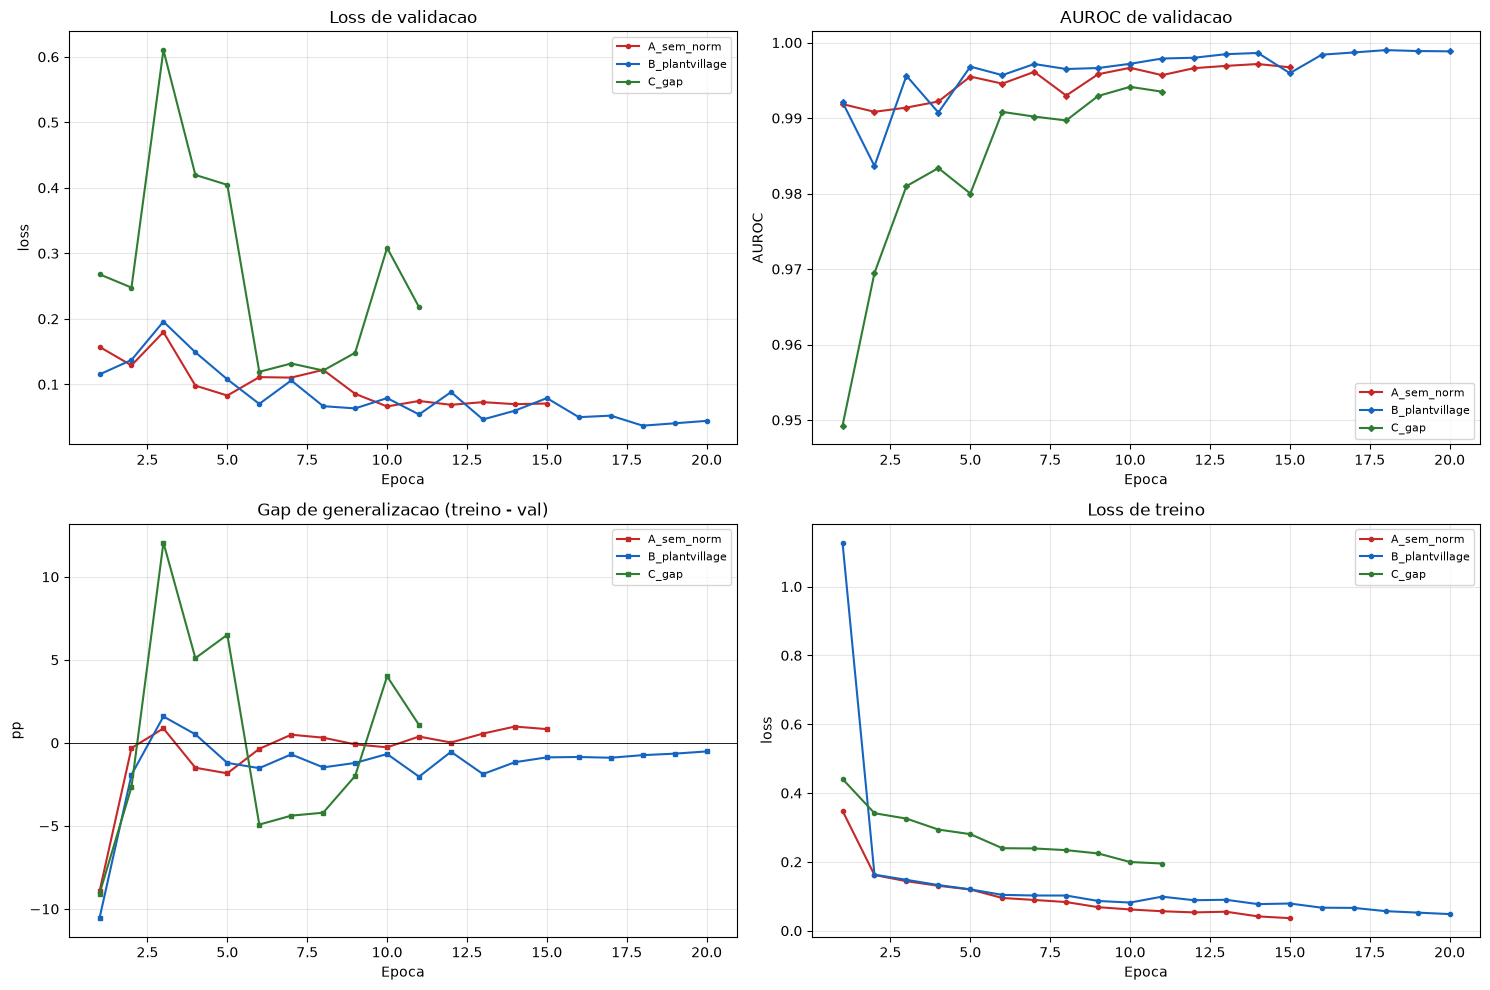

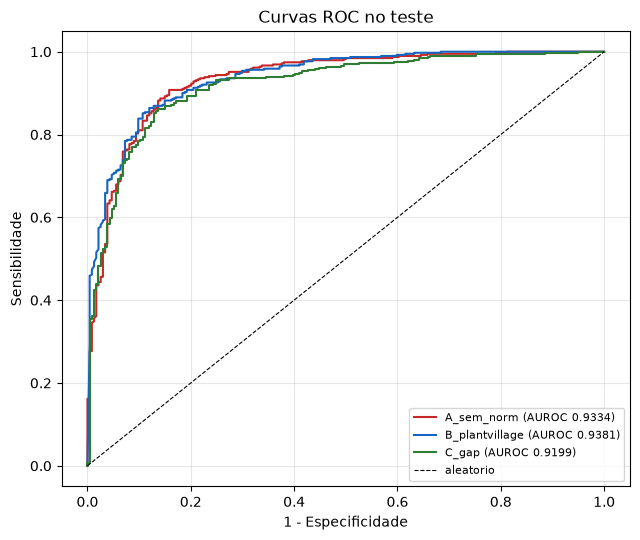

figuras em runs/projeto2/ablacao_20260828-094233/figuras


In [7]:
# ---------------------------------------------------------------
# 7. Curvas comparativas
# ---------------------------------------------------------------
colors = {'A_sem_norm': '#C62828', 'B_plantvillage': '#1565C0', 'C_gap': '#2E7D32'}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for r in results.values():
    h, ep = r['history'], range(1, len(r['history']['train_loss']) + 1)
    c = colors[r['name']]
    axes[0, 0].plot(ep, h['val_loss'], marker='o', ms=3, color=c, label=r['name'])
    axes[0, 1].plot(ep, h['val_auroc'], marker='D', ms=3, color=c, label=r['name'])
    axes[1, 0].plot(ep, np.array(h['train_acc']) - np.array(h['val_acc']),
                    marker='s', ms=3, color=c, label=r['name'])
    axes[1, 1].plot(ep, h['train_loss'], marker='o', ms=3, color=c, label=r['name'])

for ax, tit, yl in ((axes[0, 0], 'Loss de validacao', 'loss'),
                    (axes[0, 1], 'AUROC de validacao', 'AUROC'),
                    (axes[1, 0], 'Gap de generalizacao (treino - val)', 'pp'),
                    (axes[1, 1], 'Loss de treino', 'loss')):
    ax.set_title(tit); ax.set_xlabel('Epoca'); ax.set_ylabel(yl)
    ax.legend(fontsize=8); ax.grid(alpha=.3)
axes[1, 0].axhline(0, color='k', lw=.6)

plt.tight_layout()
plt.savefig(ABLATION_DIR / "figuras" / "ablacao_curvas.png", dpi=130, bbox_inches='tight')
plt.show()

# ROC no teste, as tres sobrepostas
plt.figure(figsize=(6.5, 5.5))
for r in results.values():
    px, yx = predict_probs(AblationCNN(**{k: r[k] for k in ('use_batchnorm', 'head_type')}).to(device)
                    if False else None, None) if False else (None, None)
plt.close()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, r in results.items():
    m = AblationCNN(use_batchnorm=r['use_batchnorm'],
                   head_type=r['head_type']).to(device)
    m.load_state_dict(torch.load(ABLATION_DIR / f"{name}.pt")['model'])
    px, yx = predict_probs(m, test_loader)
    fpr, tpr, _ = roc_curve(yx, px)
    ax.plot(fpr, tpr, color=colors[name],
            label=f"{name} (AUROC {roc_auc_score(yx, px):.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=.8, label='aleatorio')
ax.set_xlabel('1 - Especificidade'); ax.set_ylabel('Sensibilidade')
ax.set_title('Curvas ROC no teste'); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(ABLATION_DIR / "figuras" / "ablacao_roc.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"figuras em {ABLATION_DIR / 'figuras'}")


## O que escrever no relatório

Esta ablação produz **duas** afirmações atribuíveis, cada uma com uma única
variável alterada — que é exatamente o formato que o enunciado pede
(*"hipótese, correção, efeito medido"*).

### Hipótese A → B (BatchNorm)

> Sem normalização entre camadas, a distribuição de ativações que entra em cada
> ReLU não é controlada, o que torna o treino sensível ao learning rate e
> retarda a convergência. Espero que a versão com `BatchNorm2d` convirja em
> menos épocas e apresente curva de validação menos ruidosa.

Verifique nos números impressos: **épocas até parar**, **melhor época**, e o
formato da curva `Loss de validação` no gráfico.

### Hipótese B → C (cabeça densa)

> Com `Flatten + Linear(32768, 256)`, 98,9% dos parâmetros ficam numa única
> camada densa — cerca de 1.900 parâmetros por imagem de treino, capacidade
> suficiente para memorizar o conjunto inteiro. Substituir por
> `AdaptiveAvgPool2d(1) + Linear(128, 2)` reduz a rede em ~99% e deve **melhorar**
> a AUROC de teste, por reduzir a capacidade de memorização.

Verifique: **AUROC de teste** e **delta val−teste**. Se a AUROC subir com 90×
menos parâmetros, a hipótese está confirmada — e é um resultado
contraintuitivo, do tipo que rende boa discussão.

### Cuidado metodológico a declarar

As três arquiteturas partem da **mesma seed** (`semear()` é chamada antes de
cada uma), então a inicialização dos pesos e a ordem dos batches são idênticas.
Sem isso, a diferença medida misturaria o efeito do design com o efeito do
estado aleatório.

Ainda assim, um único run por arquitetura não dá intervalo de confiança.
Medimos anteriormente que mudar apenas o estado aleatório move a especificidade
em cerca de 3pp — portanto **diferenças menores que ~3pp em especificidade não
são conclusivas**. Diferenças de AUROC são mais estáveis. Declare essa
limitação; reconhecê-la vale mais que ignorá-la.

### Nota sobre `nn.ReLU()` vs `nn.ReLU(inplace=True)`

Este notebook usa `nn.ReLU()`, a forma das aulas. `inplace=True` sobrescreve o
tensor de entrada em vez de alocar um novo: é economia de memória, sem nenhum
efeito no resultado numérico. Não é fonte de diferença entre as arquiteturas.

A_sem_norm   (BatchNorm=False, cabeca=flatten, 8,482,626 params)
              precision    recall  f1-score   support

      NORMAL      0.944     0.436     0.596       234
   PNEUMONIA      0.744     0.985     0.848       390

    accuracy                          0.779       624
   macro avg      0.844     0.710     0.722       624
weighted avg      0.819     0.779     0.753       624

Acuracia            : 77.9%
Sensibilidade       : 98.5%
Especificidade      : 43.6%
Acuracia balanceada : 71.0%
AUROC               : 0.9334
AUPRC               : 0.9545
AUROC validacao     : 0.9967   delta +0.0632


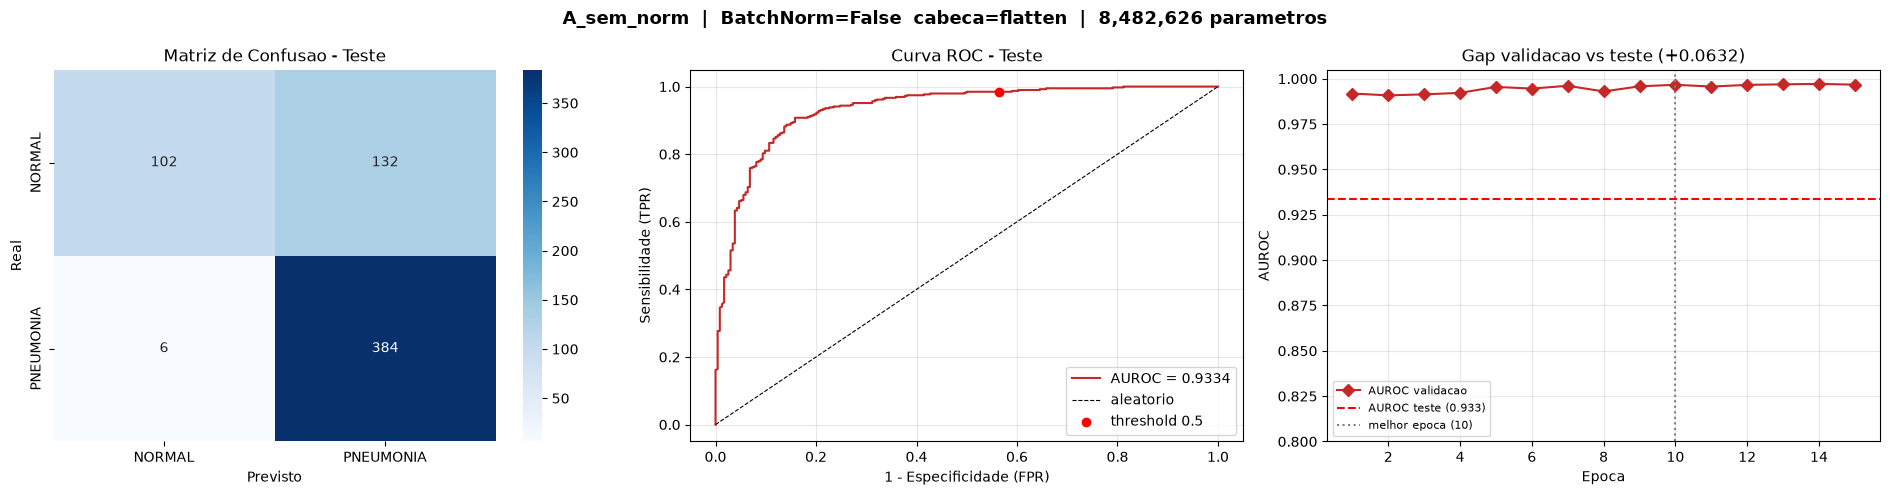

metricas salvas em runs/projeto2/ablacao_20260828-094233/A_sem_norm/metricas_teste.json



B_plantvillage   (BatchNorm=True, cabeca=flatten, 8,483,074 params)
              precision    recall  f1-score   support

      NORMAL      0.978     0.376     0.543       234
   PNEUMONIA      0.727     0.995     0.840       390

    accuracy                          0.763       624
   macro avg      0.852     0.685     0.692       624
weighted avg      0.821     0.763     0.729       624

Acuracia            : 76.3%
Sensibilidade       : 99.5%
Especificidade      : 37.6%
Acuracia balanceada : 68.5%
AUROC               : 0.9381
AUPRC               : 0.9594
AUROC validacao     : 0.9990   delta +0.0609


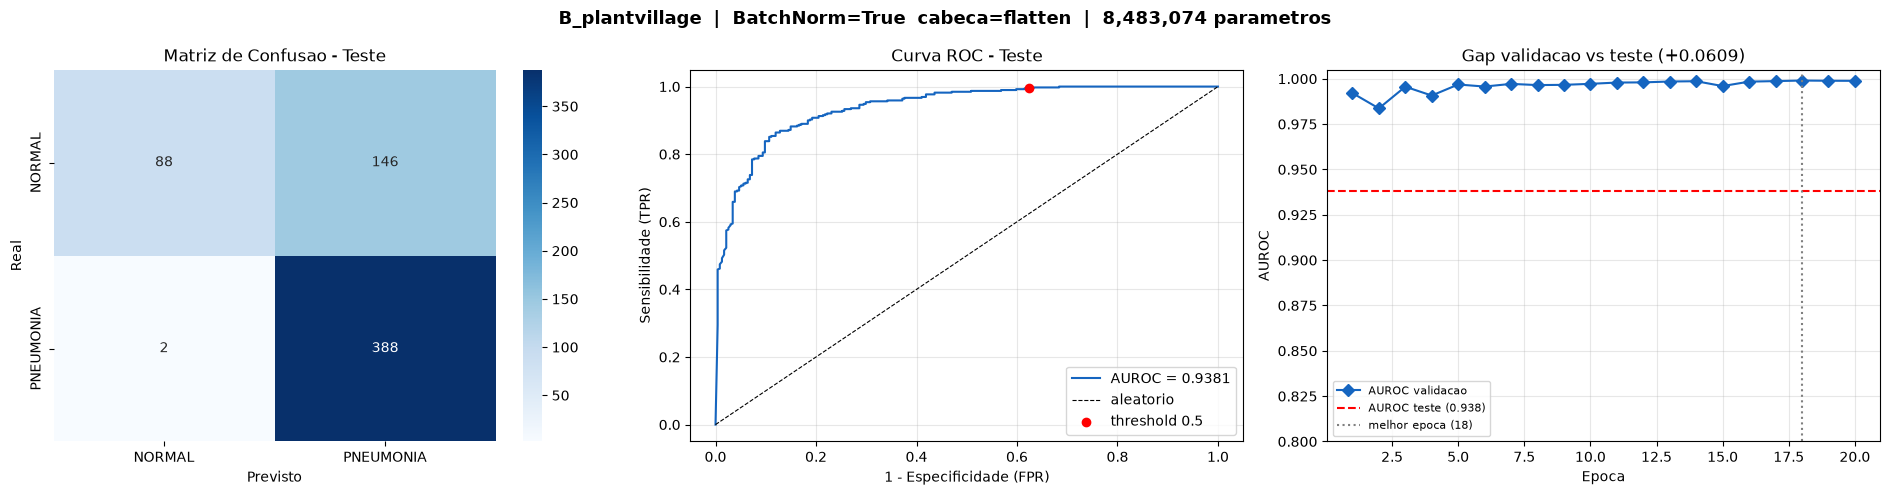

metricas salvas em runs/projeto2/ablacao_20260828-094233/B_plantvillage/metricas_teste.json



C_gap   (BatchNorm=True, cabeca=gap, 93,954 params)
              precision    recall  f1-score   support

      NORMAL      0.907     0.500     0.645       234
   PNEUMONIA      0.764     0.969     0.854       390

    accuracy                          0.793       624
   macro avg      0.835     0.735     0.749       624
weighted avg      0.817     0.793     0.776       624

Acuracia            : 79.3%
Sensibilidade       : 96.9%
Especificidade      : 50.0%
Acuracia balanceada : 73.5%
AUROC               : 0.9199
AUPRC               : 0.9429
AUROC validacao     : 0.9908   delta +0.0709


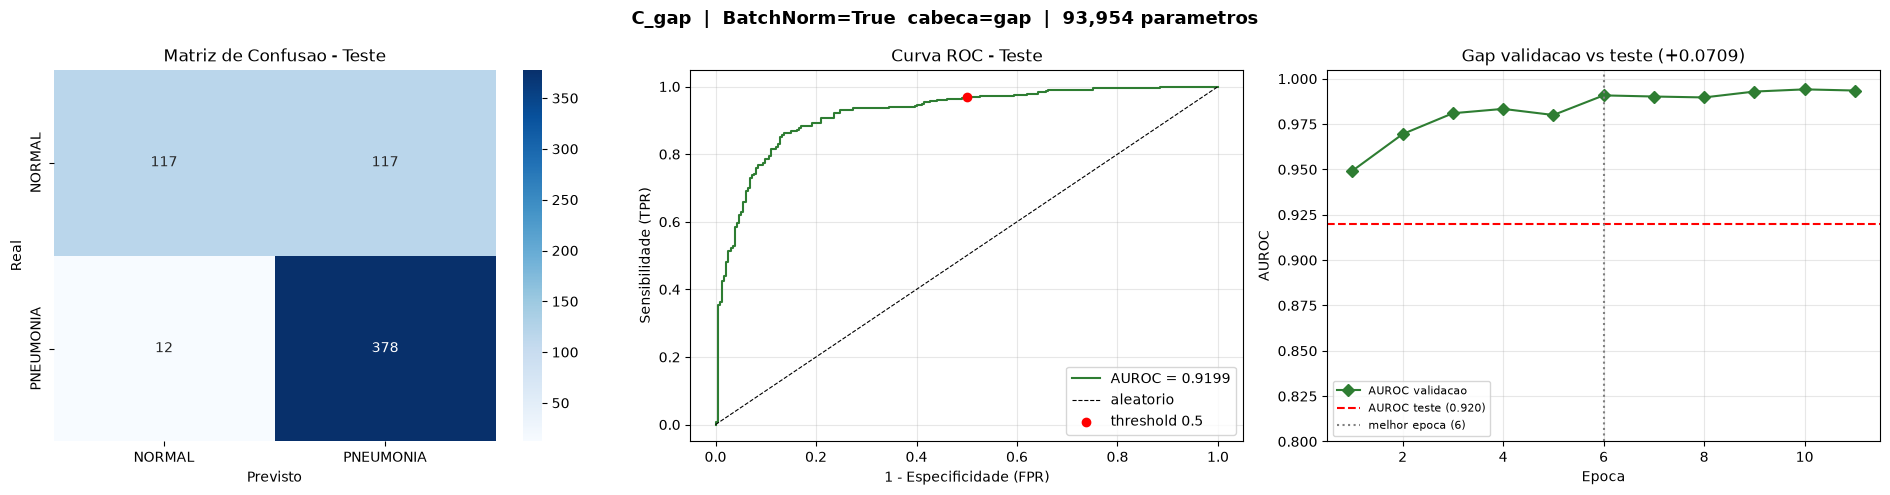

metricas salvas em runs/projeto2/ablacao_20260828-094233/C_gap/metricas_teste.json

figuras: ['A_sem_norm_avaliacao.png', 'B_plantvillage_avaliacao.png', 'C_gap_avaliacao.png']


In [8]:
# Painel de 3 graficos + metricas_teste.json por arquitetura, no mesmo formato
# do notebook da ResNet-18 para as figuras ficarem comparaveis lado a lado:
#   painel 1  matriz de confusao
#   painel 2  curva ROC com o ponto de operacao marcado
#   painel 3  AUROC de validacao por epoca contra a AUROC de teste
for name, r in results.items():
    cfg = {k: r[k] for k in ('use_batchnorm', 'head_type')}
    model = AblationCNN(**cfg).to(device)
    ckpt = torch.load(ABLATION_DIR / f"{name}.pt")
    model.load_state_dict(ckpt["model"])

    probs, test_labels = predict_probs(model, test_loader)
    m = compute_metrics(test_labels, probs)
    tn, fp, fn, tp = m['tn'], m['fp'], m['fn'], m['tp']
    sens, spec, acc, auroc = m['sens'], m['spec'], m['acc'], m['auroc']
    auprc = m['auprc']
    val_aurocs_arq = r['history']['val_auroc']
    auroc_val = r['auroc_val']
    best_epoch = r['best_epoch']
    cm = np.array([[tn, fp], [fn, tp]])

    print("=" * 72)
    print(f"{name}   (BatchNorm={cfg['use_batchnorm']}, cabeca={cfg['head_type']}, "
          f"{r['params']:,} params)")
    print("=" * 72)
    print(classification_report(test_labels, (probs >= 0.5).astype(int),
                                target_names=class_names, digits=3))
    print(f"Acuracia            : {acc:.1%}")
    print(f"Sensibilidade       : {sens:.1%}")
    print(f"Especificidade      : {spec:.1%}")
    print(f"Acuracia balanceada : {(sens+spec)/2:.1%}")
    print(f"AUROC               : {auroc:.4f}")
    print(f"AUPRC               : {auprc:.4f}")
    print(f"AUROC validacao     : {auroc_val:.4f}   delta {auroc_val-auroc:+.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    fig.suptitle(f"{name}  |  BatchNorm={cfg['use_batchnorm']}  "
                 f"cabeca={cfg['head_type']}  |  {r['params']:,} parametros",
                 fontsize=13, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')
    axes[0].set_title('Matriz de Confusao - Teste')

    fpr, tpr, _ = roc_curve(test_labels, probs)
    axes[1].plot(fpr, tpr, color=colors[name], label=f'AUROC = {auroc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=.8, label='aleatorio')
    axes[1].scatter([1 - spec], [sens], c='red', zorder=5, label='threshold 0.5')
    axes[1].set_xlabel('1 - Especificidade (FPR)')
    axes[1].set_ylabel('Sensibilidade (TPR)')
    axes[1].set_title('Curva ROC - Teste'); axes[1].legend(); axes[1].grid(alpha=.3)

    ep = range(1, len(val_aurocs_arq) + 1)
    axes[2].plot(ep, val_aurocs_arq, marker='D', color=colors[name],
                 label='AUROC validacao')
    axes[2].axhline(auroc, ls='--', color='red', label=f'AUROC teste ({auroc:.3f})')
    axes[2].axvline(best_epoch, ls=':', color='gray',
                    label=f'melhor epoca ({best_epoch})')
    axes[2].set_xlabel('Epoca'); axes[2].set_ylabel('AUROC')
    axes[2].set_ylim(0.8, 1.005)
    axes[2].set_title(f'Gap validacao vs teste ({auroc_val-auroc:+.4f})')
    axes[2].legend(fontsize=8); axes[2].grid(alpha=.3)

    plt.tight_layout()
    plt.savefig(ABLATION_DIR / "figuras" / f"{name}_avaliacao.png", dpi=130,
                bbox_inches='tight')
    plt.show()

    metrics = {
        "run": name,
        "use_batchnorm": cfg['use_batchnorm'],
        "head_type": cfg['head_type'],
        "checkpoint_epoca": int(ckpt["epoca"]),
        "matriz_confusao": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
        "accuracy": float(acc), "sensitivity": float(sens),
        "specificity": float(spec), "acuracia_balanceada": float((sens+spec)/2),
        "auroc": float(auroc), "auprc": float(auprc),
        "auroc_validacao": float(auroc_val),
        "delta_auroc_val_teste": float(auroc_val - auroc),
        "params_totais": int(r['params']),
        "epocas_rodadas": int(r['n_epochs']),
        "sweep_threshold": r['sweep'],
    }
    output_path = ABLATION_DIR / name / "metricas_teste.json"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w") as f:
        json.dump(metrics, f, indent=2)
    print(f"metricas salvas em {output_path}\n")

print("figuras:", sorted(x.name for x in (ABLATION_DIR / "figuras").glob("*_avaliacao.png")))
